<a href="https://colab.research.google.com/github/RRADJon/TEMPO/blob/main/NNfilter_training_Batch_Boltz2_Nvidia_NIM_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Make sure to visit https://build.nvidia.com/mit/boltz2 and select "get API key"
include this API key in your secrets tab under NVIDIA_API_KEY and turn on notebook access.

In [1]:
#@title Setup call to NVIDIA NIM Boltz-2 and Run
!pip install -q httpx fastapi nest_asyncio py3Dmol biopython

import asyncio
import json
import logging
import sys
import os
from typing import Any, Dict, Optional
from pathlib import Path
import httpx
from fastapi import HTTPException
from google.colab import userdata
import nest_asyncio

# Apply nest_asyncio to allow asyncio.run() to work in a notebook
nest_asyncio.apply()

# 2. Setup Logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# 3. Retrieve the Secret Key
try:
    NVIDIA_API_KEY = userdata.get('NVIDIA_API_KEY')
except Exception:
    print("Error: Make sure you added 'NVIDIA_API_KEY' to the Secrets tab and enabled Notebook access.")
    sys.exit(1)

STATUS_URL = "https://api.nvcf.nvidia.com/v2/nvcf/pexec/status/{task_id}"
PUBLIC_URL = "https://health.api.nvidia.com/v1/biology/mit/boltz2/predict"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.0 MB/s eta 0:00:00


In [2]:
#@title Functions
async def make_nvcf_call(function_url: str,
                        data: Dict[str, Any],
                        additional_headers: Optional[Dict[str, Any]] = None,
                        NVCF_POLL_SECONDS: int = 300,
                        MANUAL_TIMEOUT_SECONDS: int = 400) -> Dict:

    async with httpx.AsyncClient() as client:
        # We inject the actual API key here
        headers = {
            "Authorization": f"Bearer {NVIDIA_API_KEY}",
            "NVCF-POLL-SECONDS": f"{NVCF_POLL_SECONDS}",
            "Content-Type": "application/json"
        }
        if additional_headers:
            headers.update(additional_headers)

        response = await client.post(function_url,
                                     json=data,
                                     headers=headers,
                                     timeout=MANUAL_TIMEOUT_SECONDS)

        if response.status_code == 202:
            task_id = response.headers.get("nvcf-reqid")
            while True:
                # Poll for status
                status_response = await client.get(STATUS_URL.format(task_id=task_id),
                                                   headers=headers,
                                                   timeout=MANUAL_TIMEOUT_SECONDS)
                if status_response.status_code == 200:
                    return status_response.status_code, status_response
                elif status_response.status_code in [400, 401, 404, 422, 500]:
                    raise HTTPException(status_code=status_response.status_code, detail=status_response.text)
                await asyncio.sleep(5) # Add a small sleep to avoid spamming the poll
        elif response.status_code == 200:
            return response.status_code, response
        else:
            raise HTTPException(status_code=response.status_code, detail=response.text)


async def run_batch_predictions(
    protein_batch,
    ligand_smiles,
    output_dir="boltz2_batch_outputs"
):
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    summary_rows = []

    for idx, protein in enumerate(protein_batch, start=1):
        protein_id = protein["id"]
        sequence = protein["sequence"]

        print(f"\n🧪 [{idx}/{len(protein_batch)}] Running Boltz-2 for {protein_id}")

        payload = {
            "polymers": [
                {
                    "id": "A",
                    "molecule_type": "protein",
                    "sequence": sequence,
                    "msa": {
                        "uniref90": {
                            "a3m": {
                                "alignment": f">seq1\n{sequence}",
                                "format": "a3m"
                            }
                        }
                    }
                }
            ],
            "ligands": [
                {
                    "smiles": ligand_smiles,
                    "id": "L1",
                    "predict_affinity": True
                }
            ],
            "recycling_steps": 1,
            "sampling_steps": 50,
            "diffusion_samples": 3,
            "step_scale": 1.2,
            "without_potentials": True
        }

        try:
            code, response = await make_nvcf_call(
                function_url=PUBLIC_URL,
                data=payload
            )

            if code == 200:
                result = response.json()

                out_path = output_dir / f"{protein_id}_boltz2.json"
                out_path.write_text(json.dumps(result, indent=2))

                # ---- Extract metrics for summary ----
                affinity_root = result.get("affinity_predictions", result.get("affinities", {}))
                affinity = affinity_root.get("L1", {})

                pIC50 = affinity.get("affinity_pic50", [None])[0]
                bind_prob = affinity.get("affinity_probability_binary", [None])[0]

                summary_rows.append({
                    "Protein ID": protein_id,
                    "Sequence Length": len(sequence),
                    "pIC50": pIC50,
                    "Binding Probability": bind_prob,
                    "Result File": out_path.name
                })

                print(f"✅ Completed {protein_id}, saved → {out_path.name}")

        except Exception as e:
            print(f"❌ Failed for {protein_id}: {e}")

    return summary_rows


In [3]:
#@title Boltz-2 Dataset Builder
!pip install -q rdkit deepchem

import asyncio
import json
import time
import requests
from pathlib import Path
from rdkit import Chem
from Bio.PDB import PDBParser, PPBuilder
import deepchem as dc
import pandas as pd
import numpy as np

MAX_RETRIES = 1

print("Loading PDBbind dataset...")

tasks, datasets, transformers = dc.molnet.load_pdbbind(
    featurizer="Raw",
    set_name="refined",
    reload=True
)

train_dataset, valid_dataset, test_dataset = datasets

pdbids = train_dataset.ids[:100]
labels = train_dataset.y[:100]

dataset_rows = []

output_dir = Path("boltz_pdbbind_training")
output_dir.mkdir(exist_ok=True)

def get_protein_sequence(pdb_file):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("protein", pdb_file)
    ppb = PPBuilder()
    sequence = ""
    for pp in ppb.build_peptides(structure):
        sequence += str(pp.get_sequence())
    return sequence

def get_ligand_smiles(pdb_file):

    mol = Chem.MolFromPDBFile(pdb_file, removeHs=False)
    if mol is None:
        return None

    frags = Chem.GetMolFrags(mol, asMols=True)

    if len(frags) == 0:
        return None

    # choose smallest fragment as ligand candidate
    ligand = sorted(frags, key=lambda m: m.GetNumAtoms())[0]

    try:
        smiles = Chem.MolToSmiles(ligand)
        return smiles
    except:
        return None


# Boltz-2 call with retry logic

async def run_boltz(payload):

    for attempt in range(MAX_RETRIES):

        try:

            code, response = await make_nvcf_call(
                function_url=PUBLIC_URL,
                data=payload
            )

            if code == 200:
                return response.json()

        except Exception as e:

            error_text = str(e)

            if "429" in error_text:

                wait = 2 * (attempt + 1)

                print(f"Rate limited. Waiting {wait}s...")
                time.sleep(wait)

                continue

            else:
                print("Skipping due to error:", e)
                return None

    return None


# -------------------------------------------------
# Build dataset
# -------------------------------------------------

async def build_dataset():

    for i,(pdbid,affinity) in enumerate(zip(pdbids,labels)):

        print(f"\nRunning Boltz-2 for {pdbid} ({i+1}/{len(pdbids)})")

        pdb_url = f"https://files.rcsb.org/download/{pdbid}.pdb"
        pdb_file = f"{pdbid}.pdb"

        r = requests.get(pdb_url)

        if r.status_code != 200:
            print("Download failed")
            continue

        open(pdb_file,"wb").write(r.content)

        sequence = get_protein_sequence(pdb_file)
        ligand   = get_ligand_smiles(pdb_file)

        if sequence is None or ligand is None:
            print("Failed to parse complex")
            continue

        payload = {
            "polymers":[
                {
                    "id":"A",
                    "molecule_type":"protein",
                    "sequence":sequence,
                    "msa":{
                        "uniref90":{
                            "a3m":{
                                "alignment":f">seq\n{sequence}",
                                "format":"a3m"
                            }
                        }
                    }
                }
            ],
            "ligands":[
                {
                    "smiles":ligand,
                    "id":"L1",
                    "predict_affinity":True
                }
            ],
            "recycling_steps":1,
            "sampling_steps":50,
            "diffusion_samples":3
        }

        result = await run_boltz(payload)

        if result is None:
            continue

        out_file = output_dir / f"{pdbid}.json"
        out_file.write_text(json.dumps(result,indent=2))

        affinity_root = result.get("affinity_predictions", result.get("affinities", {}))
        affinity_pred = affinity_root.get("L1",{})

        pic50 = affinity_pred.get("affinity_pic50",[None])[0]
        prob  = affinity_pred.get("affinity_probability_binary",[None])[0]

        conf = np.mean(result.get("confidence_scores",[0]))

        dataset_rows.append({
            "pdbid":pdbid,
            "true_affinity":float(affinity),
            "boltz_pic50":pic50,
            "boltz_prob":prob,
            "confidence":conf
        })

    return dataset_rows


dataset_rows = asyncio.run(build_dataset())

df_dataset = pd.DataFrame(dataset_rows)

df_dataset.to_csv("boltz_pdbbind_dataset.csv",index=False)

print("\nDataset built:")
display(df_dataset.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.4/552.4 kB 20.2 MB/s eta 0:00:00
ERROR: Operation cancelled by user


KeyboardInterrupt: 

In [ ]:
#@title Boltz-2 False Binder Dataset Builder (Shuffled Ligands)

import asyncio
import json
import time
import requests
from pathlib import Path
from rdkit import Chem
from Bio.PDB import PDBParser, PPBuilder
import deepchem as dc
import pandas as pd
import numpy as np
import random

MAX_RETRIES = 2

print("Loading PDBbind dataset...")

tasks, datasets, transformers = dc.molnet.load_pdbbind(
    featurizer="Raw",
    set_name="refined",
    reload=True
)

train_dataset, valid_dataset, test_dataset = datasets

pdbids = train_dataset.ids[:100]
labels = train_dataset.y[:100]

dataset_rows = []

output_dir = Path("boltz_pdbbind_false_binders")
output_dir.mkdir(exist_ok=True)

# -------------------------------------------------
# Helpers
# -------------------------------------------------

def get_protein_sequence(pdb_file):

    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("protein", pdb_file)

    ppb = PPBuilder()
    sequence = ""

    for pp in ppb.build_peptides(structure):
        sequence += str(pp.get_sequence())

    return sequence


def get_ligand_smiles(pdb_file):

    mol = Chem.MolFromPDBFile(pdb_file, removeHs=False)

    if mol is None:
        return None

    frags = Chem.GetMolFrags(mol, asMols=True)

    if len(frags) == 0:
        return None

    ligand = sorted(frags, key=lambda m: m.GetNumAtoms())[0]

    try:
        smiles = Chem.MolToSmiles(ligand)
        return smiles
    except:
        return None


async def run_boltz(payload):

    for attempt in range(MAX_RETRIES):

        try:

            code, response = await make_nvcf_call(
                function_url=PUBLIC_URL,
                data=payload
            )

            if code == 200:
                return response.json()

        except Exception as e:

            error_text = str(e)

            if "429" in error_text:

                wait = 10 * (attempt + 1)

                print(f"Rate limited. Waiting {wait}s...")
                time.sleep(wait)

                continue

            else:
                print("Skipping due to error:", e)
                return None

    return None


# -------------------------------------------------
# Download PDBs and extract sequences + ligands
# -------------------------------------------------

print("Downloading structures and extracting ligands...")

protein_sequences = {}
ligands = {}

for pdbid in pdbids:

    pdb_url = f"https://files.rcsb.org/download/{pdbid}.pdb"
    pdb_file = f"{pdbid}.pdb"

    r = requests.get(pdb_url)

    if r.status_code != 200:
        print("Download failed:", pdbid)
        continue

    open(pdb_file,"wb").write(r.content)

    seq = get_protein_sequence(pdb_file)
    lig = get_ligand_smiles(pdb_file)

    if seq is None or lig is None:
        print("Parse failed:", pdbid)
        continue

    protein_sequences[pdbid] = seq
    ligands[pdbid] = lig


# -------------------------------------------------
# Shuffle ligands
# -------------------------------------------------

print("Shuffling ligands to create false binders...")

ligand_list = list(ligands.values())
random.shuffle(ligand_list)

shuffled_pairs = list(zip(protein_sequences.keys(), ligand_list))


# -------------------------------------------------
# Build FALSE binder dataset
# -------------------------------------------------

async def build_false_dataset():

    for i,(pdbid,ligand) in enumerate(shuffled_pairs):

        print(f"\nRunning Boltz-2 FALSE pair {i+1}/{len(shuffled_pairs)}")

        sequence = protein_sequences[pdbid]

        payload = {

            "polymers":[
                {
                    "id":"A",
                    "molecule_type":"protein",
                    "sequence":sequence,
                    "msa":{
                        "uniref90":{
                            "a3m":{
                                "alignment":f">seq\n{sequence}",
                                "format":"a3m"
                            }
                        }
                    }
                }
            ],

            "ligands":[
                {
                    "smiles":ligand,
                    "id":"L1",
                    "predict_affinity":True
                }
            ],

            "recycling_steps":1,
            "sampling_steps":50,
            "diffusion_samples":3
        }

        result = await run_boltz(payload)

        if result is None:
            continue

        out_file = output_dir / f"{pdbid}_false.json"
        out_file.write_text(json.dumps(result,indent=2))

        affinity_root = result.get("affinity_predictions", result.get("affinities", {}))
        affinity_pred = affinity_root.get("L1",{})

        pic50 = affinity_pred.get("affinity_pic50",[None])[0]
        prob  = affinity_pred.get("affinity_probability_binary",[None])[0]

        conf = np.mean(result.get("confidence_scores",[0]))

        dataset_rows.append({
            "pdbid":pdbid,
            "boltz_pic50":pic50,
            "boltz_prob":prob,
            "confidence":conf,
            "binder":0
        })

    return dataset_rows


dataset_rows = asyncio.run(build_false_dataset())

df_false = pd.DataFrame(dataset_rows)

df_false.to_csv("boltz_false_binders.csv",index=False)

print("\nFalse binder dataset built")
display(df_false.head())

In [ ]:
# ============================================================
#@title Convert Boltz JSON Predictions to Training Dataset
# ============================================================

import json
import numpy as np
import pandas as pd
from pathlib import Path

boltz_dir = Path("boltz_pdbbind_training")

rows = []

print("Parsing Boltz outputs...")

for file in boltz_dir.glob("*.json"):

    with open(file) as f:
        result = json.load(f)

    pdbid = file.stem

    affinity_root = result.get("affinity_predictions",
                               result.get("affinities", {}))

    affinity = affinity_root.get("L1", {})

    pic50 = affinity.get("affinity_pic50",[None])[0]
    prob  = affinity.get("affinity_probability_binary",[None])[0]

    if pic50 is None or prob is None:
        continue

    conf_scores = result.get("confidence_scores",[0])
    confidence  = np.mean(conf_scores)

    seq_len = 0
    if "structures" in result and len(result["structures"])>0:
        seq_len = len(result["structures"][0]["structure"])

    rows.append({
        "pdbid": pdbid,
        "boltz_pic50": pic50,
        "boltz_prob": prob,
        "confidence": confidence,
        "seq_len": seq_len
    })

df_features = pd.DataFrame(rows)

print("Boltz dataset size:", len(df_features))

display(df_features.head())

df_features.to_csv("boltz_nn_features.csv",index=False)

print("Saved dataset → boltz_nn_features.csv")

In [4]:
# ============================================================
#@title Upload and Restore Boltz Dataset Backup
# ============================================================

from google.colab import files
import tarfile
from pathlib import Path
import pandas as pd
import json

print("Upload boltz_dataset_backup.tar.gz")

uploaded = files.upload()

archive_name = list(uploaded.keys())[0]

print("\nExtracting dataset...")

with tarfile.open(archive_name,"r:gz") as tar:
    tar.extractall()

dataset_dir = Path("boltz_dataset_false")

print("Dataset extracted")

# ------------------------------------------------
# Restore directories
# ------------------------------------------------

dirs = [
    "boltz_pdbbind_training",
    "boltz_pdbbind_false_binders",
    "pdb_structures"
]

for d in dirs:

    src = dataset_dir / d

    if src.exists():

        Path(d).mkdir(exist_ok=True)

        for file in src.glob("*"):
            target = Path(d) / file.name
            target.write_bytes(file.read_bytes())

        print("Restored:", d)

# ------------------------------------------------
# Load datasets
# ------------------------------------------------

datasets = {}

csv_files = [
    "boltz_pdbbind_dataset.csv",
    "boltz_false_binders.csv",
    "boltz_training_dataset_balanced.csv"
]

for f in csv_files:

    path = dataset_dir / f

    if path.exists():

        df = pd.read_csv(path)

        datasets[f] = df

        print("Loaded:", f, "| rows:", len(df))

# ------------------------------------------------
# Restore ligand bank
# ------------------------------------------------

ligand_bank = {}

lig_file = dataset_dir / "ligand_bank.json"

if lig_file.exists():

    with open(lig_file) as f:
        ligand_bank = json.load(f)

    print("Ligand bank restored:", len(ligand_bank))

# ------------------------------------------------
# Display dataset preview
# ------------------------------------------------

if "boltz_training_dataset_balanced.csv" in datasets:

    df = datasets["boltz_training_dataset_balanced.csv"]

else:

    df = pd.concat([
        datasets.get("boltz_pdbbind_dataset.csv",pd.DataFrame()),
        datasets.get("boltz_false_binders.csv",pd.DataFrame())
    ])

print("\nCombined dataset preview:")
display(df.head())

print("\nDataset ready for training")

Upload boltz_dataset_backup.tar.gz


Saving boltz_dataset_backup (1).tar.gz to boltz_dataset_backup (1).tar.gz

Extracting dataset...


/tmp/ipykernel_1134/1080974428.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Dataset extracted

Combined dataset preview:


""



Dataset ready for training


In [ ]:
# ---------------------------------------------------
#@title  Export Combined Dataset as TGZ (including PDBs)
# ---------------------------------------------------

import tarfile
from pathlib import Path

export_dir = Path("boltz_pdbbind_export")
export_dir.mkdir(exist_ok=True)

# Copy all PDB structures into export folder
pdb_src_dirs = [
    Path("."),  # home directory where PDBs may be
    Path("boltz_pdbbind_structures")  # any additional folder with structures
]

for pdb_dir in pdb_src_dirs:
    if pdb_dir.exists():
        for pdb_file in pdb_dir.glob("*.pdb"):
            dest_file = export_dir / pdb_file.name
            dest_file.write_bytes(pdb_file.read_bytes())

# Ensure combined dataset CSV is included
required_columns = [
    "pdbid", "ligand_smiles", "true_affinity", "boltz_pic50",
    "boltz_prob", "confidence", "num_contacts",
    "mean_contact_score", "max_contact_score", "binder_label"
]

for col in required_columns:
    if col not in combined_df.columns:
        combined_df[col] = None

csv_file = export_dir / "boltz_pdbbind_full_dataset.csv"
combined_df[required_columns].to_csv(csv_file, index=False)

# Create a .tgz archive of the entire folder
archive_file = Path("boltz_pdbbind_full_dataset.tgz")
with tarfile.open(archive_file, "w:gz") as tar:
    tar.add(export_dir, arcname=export_dir.name)

print(f"Dataset export complete! Archive saved as {archive_file}")

In [6]:
# ============================================================
# @title Merge Boltz Dataset + Manual Contact Calculation (RELIABLE)
# ============================================================

import pandas as pd
import numpy as np
import json
import io
from pathlib import Path
from Bio.PDB.MMCIFParser import MMCIFParser
from scipy.spatial.distance import cdist

# Load the base dataset
combined_df = pd.read_csv("boltz_missing_dataset.csv")
parser = MMCIFParser(QUIET=True)

def calculate_geometry_only(json_path):
    """Only extracts the 3D distance bins from the JSON."""
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)

        cif_string = data["structures"][0]["structure"]
        handle = io.StringIO(cif_string)
        structure = parser.get_structure("complex", handle)

        protein_coords = []
        ligand_coords  = []

        for atom in structure.get_atoms():
            resname = atom.get_parent().get_resname()
            if resname == "LIG1" or len(resname) > 3:
                ligand_coords.append(atom.get_coord())
            else:
                protein_coords.append(atom.get_coord())

        if not protein_coords or not ligand_coords:
            return [0.0] * 5 # 4 bins + 1 total count

        p_arr, l_arr = np.array(protein_coords), np.array(ligand_coords)
        dists = cdist(p_arr, l_arr)

        return [
            float(np.sum(dists < 2.5)),
            float(np.sum((dists >= 2.5) & (dists < 3.5))),
            float(np.sum((dists >= 3.5) & (dists < 4.5))),
            float(np.sum((dists >= 4.5) & (dists < 6.0))),
            float(np.sum(dists < 5.0)) # total_contacts proxy
        ]
    except:
        return [0.0] * 5

# --- Execution ---
true_json_dir  = Path("boltz_dataset_true/boltz_pdbbind_training")
false_json_dir = Path("boltz_dataset/boltz_pdbbind_false_binders")

geo_results = []
for _, row in combined_df.iterrows():
    pdbid = row["pdbid"]
    t_path, f_path = true_json_dir / f"{pdbid}.json", false_json_dir / f"{pdbid}_false.json"
    target = t_path if t_path.exists() else (f_path if f_path.exists() else None)
    geo_results.append(calculate_geometry_only(target) if target else [0.0]*5)

# Create Geometry DataFrame
geo_cols = ["bin_0_2.5", "bin_2.5_3.5", "bin_3.5_4.5", "bin_4.5_6.0", "num_contacts"]
geo_df = pd.DataFrame(geo_results, columns=geo_cols)

# Merge
combined_df = pd.concat([combined_df.reset_index(drop=True), geo_df], axis=1)

# --- MAP CONFIDENCE FROM CSV DIRECTLY (NO JSON HUNTING) ---
# We use the 'confidence' column already in combined_df
combined_df["mean_contact_prob"] = combined_df["confidence"].astype(float)
combined_df["max_contact_prob"] = combined_df["confidence"].astype(float)

# Distribute contacts into confidence bins based on the CSV confidence
def bin_conf(row):
    c = row["num_contacts"]
    conf = row["confidence"]
    if conf >= 0.7: return pd.Series([c, 0.0, 0.0])
    if conf >= 0.3: return pd.Series([0.0, c, 0.0])
    return pd.Series([0.0, 0.0, c])

combined_df[["high_conf_contacts", "med_conf_contacts", "low_conf_contacts"]] = combined_df.apply(bin_conf, axis=1)

# --- RECALCULATE RATIOS ---
combined_df["contact_density"] = combined_df["num_contacts"] / (combined_df["confidence"] + 1e-6)
combined_df["affinity_contact_ratio"] = combined_df["boltz_pic50"] * combined_df["mean_contact_prob"]

print("Final Check (Using CSV Confidence):")
print(combined_df[["pdbid", "boltz_pic50", "mean_contact_prob", "affinity_contact_ratio"]].head())

combined_df.to_csv("boltz_training_dataset_balanced.csv", index=False)

Final Check (Using CSV Confidence):
  pdbid  boltz_pic50  mean_contact_prob  affinity_contact_ratio
0  5mmg     8.028152           0.924493                7.421974
1  5igm     6.319156           0.830798                5.249941
2  5mrp     8.206312           0.524095                4.300889
3  1ype     7.166328           0.900446                6.452888
4  3qtv     5.434688           0.888479                4.828607


In [11]:
# @title NN Training (Binary Classifier Integrated)
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import permutation_importance
from rdkit import Chem
from rdkit.Chem import Descriptors

# 1. Load dataset
combined_df = pd.read_csv("boltz_training_dataset_balanced.csv").fillna(0)

# 2. Compute ligand descriptors (Skips if no SMILES column found)
ligand_features = ["mol_wt","logp","h_donors","h_acceptors","tpsa","rotatable_bonds"]
def compute_ligand(smiles):
    if pd.isna(smiles) or str(smiles) == "0": return [0]*6
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return [0]*6
    return [
        Descriptors.MolWt(mol), Descriptors.MolLogP(mol),
        Descriptors.NumHDonors(mol), Descriptors.NumHAcceptors(mol),
        Descriptors.TPSA(mol), Descriptors.NumRotatableBonds(mol)
    ]

# Check for SMILES column (handling multiple naming possibilities)
smiles_col = next((c for c in combined_df.columns if c.lower() in ['ligand_smiles', 'smiles']), None)

if smiles_col:
    print(f"Computing ligand descriptors from '{smiles_col}'...")
    ligand_df = pd.DataFrame(combined_df[smiles_col].apply(compute_ligand).tolist(), columns=ligand_features)
    combined_df = pd.concat([combined_df.reset_index(drop=True), ligand_df], axis=1)
else:
    for f in ligand_features: combined_df[f] = 0
    print("⚠ No SMILES column found — ligand features set to 0")

# 3. Feature Selection & Mapping
# We ensure the columns in your CSV match the feature list exactly
features = [
    "boltz_pic50","boltz_prob","confidence",
    "contact_bin_0_2.5","contact_bin_2.5_3.5","contact_bin_3.5_4.5","contact_bin_4.5_6",
    "strong_contacts","weak_contacts","contact_density","affinity_contact_ratio"
] + ligand_features

# Create missing features from available data
if "contact_bin_4.5_6.0" in combined_df.columns:
    combined_df["contact_bin_4.5_6"] = combined_df["contact_bin_4.5_6.0"]

X_raw = combined_df[features].values
y = combined_df["binder"].values

# 4. Transformations
# Log transform counts (indices 3-11 + 11, 16 for ligand traits)
log_idx = list(range(3, 11)) + [11, 15]
X_raw[:, log_idx] = np.log1p(np.maximum(X_raw[:, log_idx], 0))

# Interaction terms (Creates the expanded feature set)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_inter = poly.fit_transform(X_raw)
feature_names = poly.get_feature_names_out(features)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_inter)

# 5. Split and Tensor Conversion
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, stratify=y, random_state=42
)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

# 6. Neural Network
class BinderNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid() # This makes it a binary classifier (outputs probability)
        )
    def forward(self, x): return self.net(x)

# 7. Training Function
def train_model(X_train, y_train, X_test, y_test, epochs=400, lr=0.001):
    model = BinderNet(X_train.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    criterion = nn.BCELoss()

    train_losses, test_accs = [], []
    best_acc, best_state = 0, None

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train), y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        if epoch % 10 == 0 or epoch == epochs-1:
            model.eval()
            with torch.no_grad():
                # Binary Step: Probability > 0.5 = 1, else 0
                preds = (model(X_test) > 0.5).float()
                acc = accuracy_score(y_test, preds.numpy())
                test_accs.append(acc)
                if acc > best_acc:
                    best_acc = acc
                    best_state = model.state_dict()
            if epoch % 100 == 0:
                print(f"Epoch {epoch:03d} | Loss {loss.item():.4f} | Test Acc {acc:.3f}")

    model.load_state_dict(best_state)
    return model, train_losses, test_accs, best_acc

# 8. Train and Evaluate
best_model, final_losses, final_accs, best_acc = train_model(X_train_t, y_train_t, X_test_t, y_test)
print(f"\n✅ Training Complete. Best Accuracy: {best_acc:.3f}")

# Final Classification Report
best_model.eval()
with torch.no_grad():
    y_pred = (best_model(X_test_t) > 0.5).numpy().astype(int)
    print("\n--- Binary Classification Report ---")
    print(classification_report(y_test, y_pred))

# 9. Save Artifacts
torch.save(best_model.state_dict(), "best_binder_model.pt")
print("Model artifacts saved.")

⚠ No SMILES column found — ligand features set to 0
Epoch 000 | Loss 0.6889 | Test Acc 0.581
Epoch 100 | Loss 0.6418 | Test Acc 0.558
Epoch 200 | Loss 0.5946 | Test Acc 0.651
Epoch 300 | Loss 0.5263 | Test Acc 0.674

✅ Training Complete. Best Accuracy: 0.721

--- Binary Classification Report ---
              precision    recall  f1-score   support

           0       0.66      0.79      0.72        24
           1       0.64      0.47      0.55        19

    accuracy                           0.65        43
   macro avg       0.65      0.63      0.63        43
weighted avg       0.65      0.65      0.64        43

Model artifacts saved.


In [12]:
#@title Figure: Predicted Binding Pocket & Contacts
import py3Dmol
import glob
df_dataset = pd.read_csv("boltz_training_dataset_balanced.csv")

def visualize_boltz_pose(pdbid, is_false=False):
    pdb_path = f"boltz_dataset/pdb_structures/{pdbid}.pdb"

    if not Path(pdb_path).exists():
        print(f"PDB file for {pdbid} not found.")
        return

    view = py3Dmol.view(width=800, height=500)
    with open(pdb_path, 'r') as f:
        pdb_data = f.read()

    view.addModel(pdb_data, 'pdb')

    # Protein Style
    view.setStyle({'cartoon': {'color': 'yellow', 'opacity': 0.8}})
    # Boltz usually labels the ligand as 'L1' or 'LIG'
    view.addStyle({'resn': 'L1'}, {'stick': {'colorscheme': 'magentaCarbon', 'radius': 0.3}})
    view.addStyle({'resn': 'LIG1'}, {'stick': {'colorscheme': 'magentaCarbon', 'radius': 0.3}})

    # Highlight Contact Residues (Within 4.0 Angstroms of Ligand)
    #view.addSurface(py3Dmol.VDW, {'opacity': 0.3, 'color': 'white'}, {'not': {'resn': 'L1'}})

    #view.zoomTo({'resn': 'LIG1'})
    print(f"Visualizing Complex: {pdbid} | Label: {'True Binder' if not is_false else 'False Binder'}")
    return view.show()

# Example: Visualize the first PDB in your true dataset
sample_pdb = df_dataset['pdbid'].iloc[0]
visualize_boltz_pose(sample_pdb)

Visualizing Complex: 5mmg | Label: True Binder


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

ℹ️ 'mean_contact_prob' not found. Falling back to 'contact_density' for visualization.


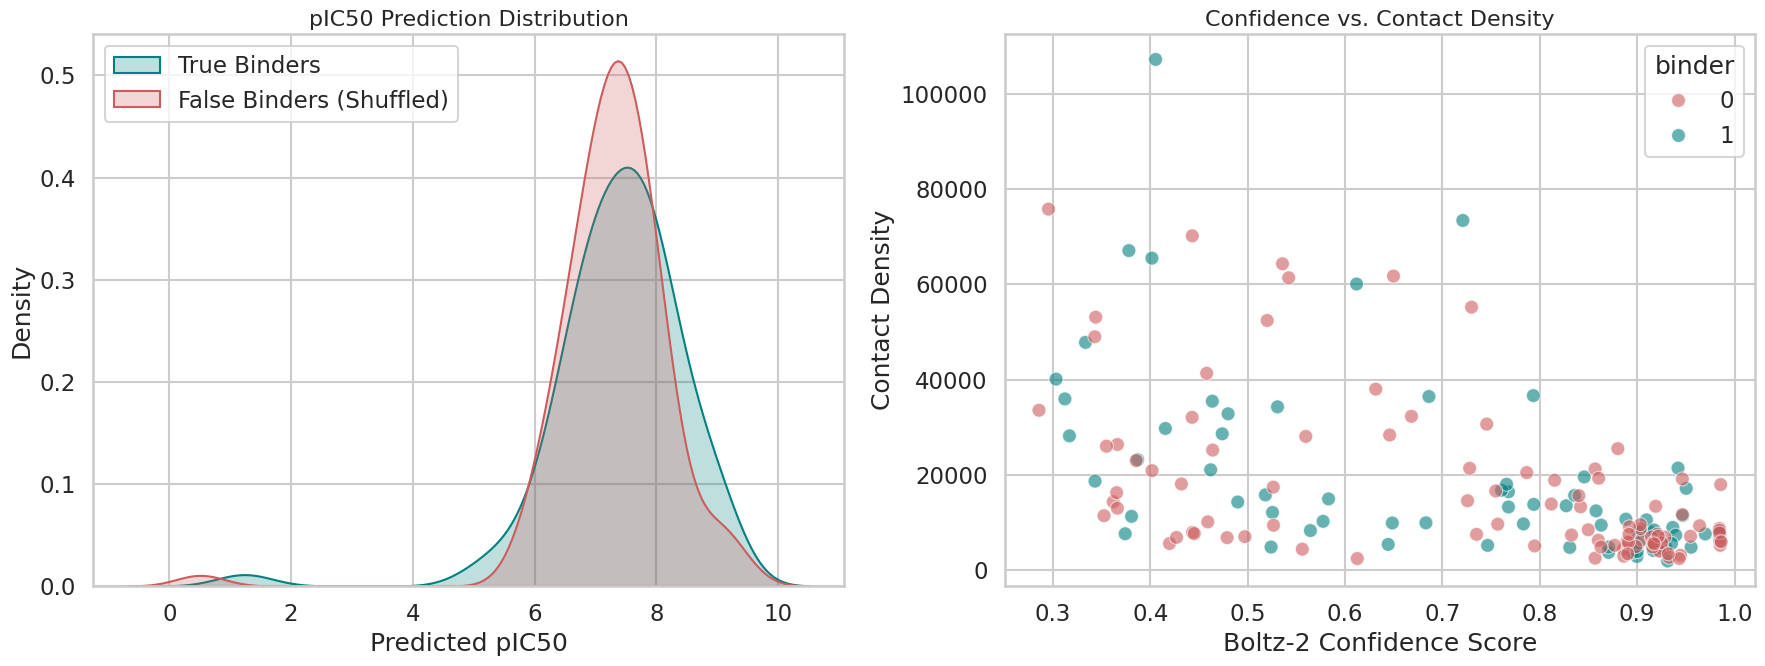

In [13]:
#@title Figure: Model Discrimination (True vs. Shuffled Ligands)
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we have a column to plot on the Y-axis if mean_contact_prob is missing
y_col = 'mean_contact_prob'
if y_col not in combined_df.columns:
    # Fallback to another structural metric if mean_contact_prob wasn't calculated
    y_col = 'contact_density' if 'contact_density' in combined_df.columns else 'num_contacts'
    print(f"ℹ️ 'mean_contact_prob' not found. Falling back to '{y_col}' for visualization.")

sns.set_theme(style="whitegrid", context="talk")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: pIC50 Distribution (True vs False)
if 'boltz_pic50' in combined_df.columns:
    sns.kdeplot(data=combined_df[combined_df['binder']==1], x='boltz_pic50',
                fill=True, label='True Binders', color='teal', ax=ax1)
    sns.kdeplot(data=combined_df[combined_df['binder']==0], x='boltz_pic50',
                fill=True, label='False Binders (Shuffled)', color='indianred', ax=ax1)
    ax1.set_title("pIC50 Prediction Distribution", fontsize=16)
    ax1.set_xlabel("Predicted pIC50")
    ax1.legend()
else:
    ax1.text(0.5, 0.5, "boltz_pic50 column missing", ha='center')

# Plot 2: Confidence vs. Structural Metric
if 'confidence' in combined_df.columns and y_col in combined_df.columns:
    sns.scatterplot(data=combined_df, x='confidence', y=y_col,
                    hue='binder', palette={1: 'teal', 0: 'indianred'},
                    alpha=0.6, s=100, ax=ax2)
    ax2.set_title(f"Confidence vs. {y_col.replace('_', ' ').title()}", fontsize=16)
    ax2.set_xlabel("Boltz-2 Confidence Score")
    ax2.set_ylabel(y_col.replace('_', ' ').title())
else:
    ax2.text(0.5, 0.5, "Required columns for scatter missing", ha='center')

plt.tight_layout()
plt.savefig("boltz_performance_summary.png", dpi=300)
plt.show()

/tmp/ipykernel_1134/2871821223.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Drop', y='Feature', data=importance_data, palette='mako', ax=ax2)


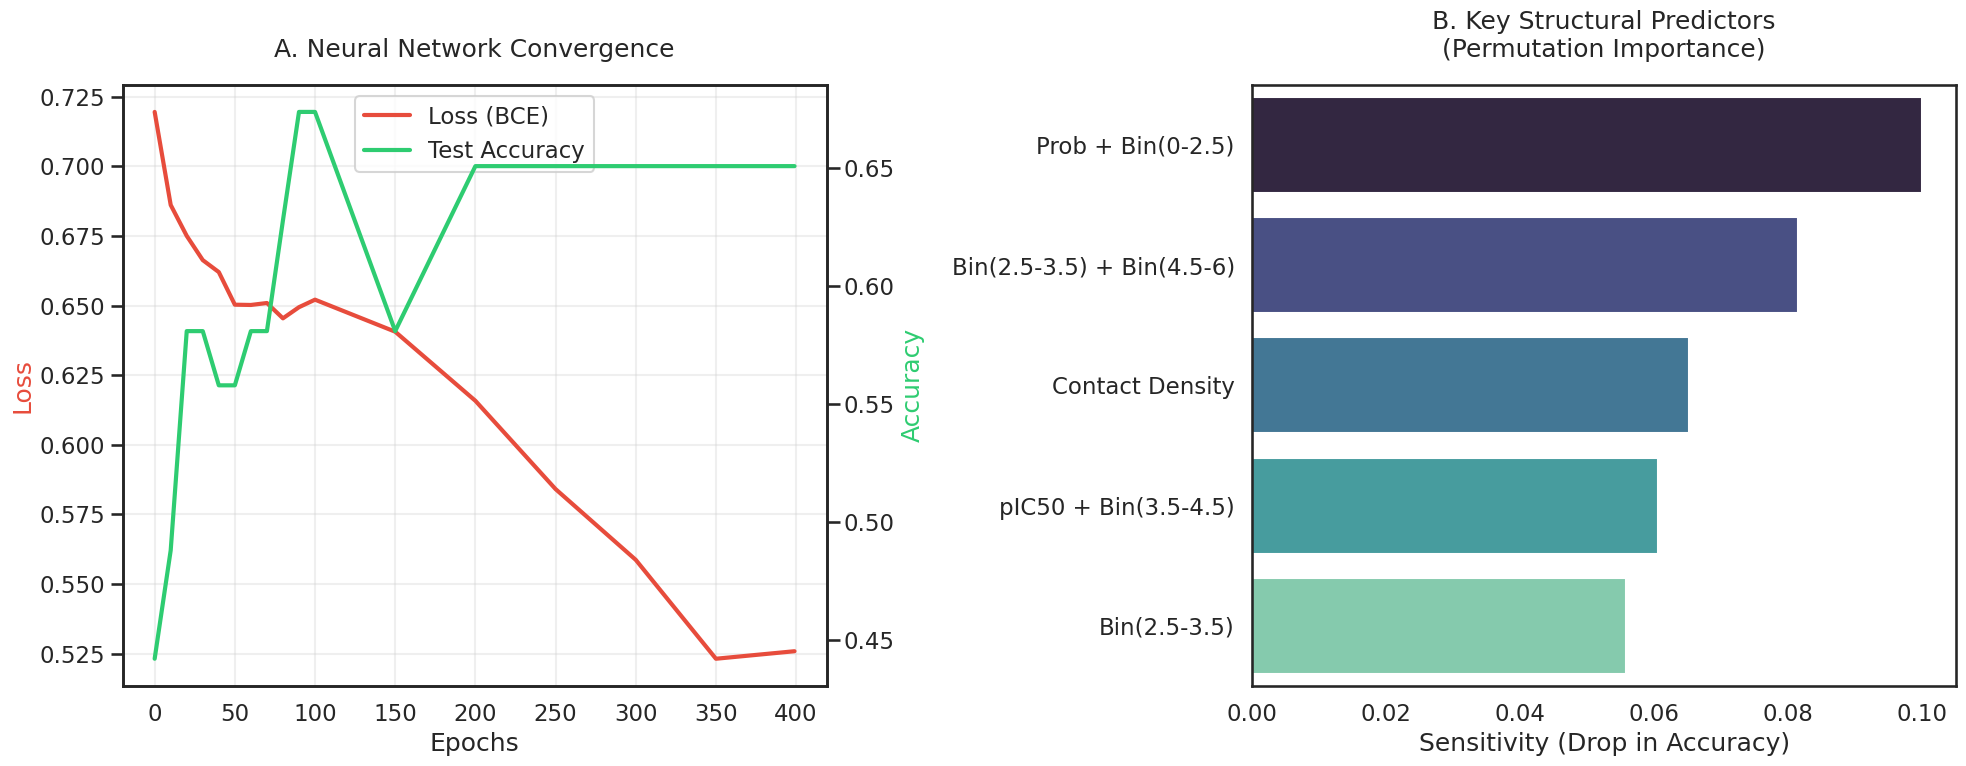

In [14]:
#@title Generate Training & Structural Insight Figures
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETUP DATA FROM YOUR RESULTS
epochs = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200, 250, 300, 350, 399]
loss = [0.7195, 0.6861, 0.6750, 0.6663, 0.6620, 0.6503, 0.6502, 0.6509, 0.6454, 0.6494, 0.6521, 0.6406, 0.6158, 0.5841, 0.5587, 0.5232, 0.5259]
accuracy = [0.442, 0.488, 0.581, 0.581, 0.558, 0.558, 0.581, 0.581, 0.628, 0.674, 0.674, 0.581, 0.651, 0.651, 0.651, 0.651, 0.651]

# Importance data from your rank table
importance_data = {
    'Feature': ['Prob + Bin(0-2.5)', 'Bin(2.5-3.5) + Bin(4.5-6)', 'Contact Density', 'pIC50 + Bin(3.5-4.5)', 'Bin(2.5-3.5)'],
    'Drop': [0.1000, 0.0814, 0.0651, 0.0605, 0.0558]
}

sns.set_theme(style="white", context="talk")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# PLOT 1: TRAINING CURVES
ax1b = ax1.twinx()
line1, = ax1.plot(epochs, loss, color='#e74c3c', lw=3, label='Loss (BCE)')
line2, = ax1b.plot(epochs, accuracy, color='#2ecc71', lw=3, label='Test Accuracy')

ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color='#e74c3c')
ax1b.set_ylabel('Accuracy', color='#2ecc71')
ax1.set_title('A. Neural Network Convergence', fontsize=18, pad=20)
ax1.grid(alpha=0.3)

# Combine legends
lines = [line1, line2]
ax1.legend(lines, [l.get_label() for l in lines], loc='upper center')

# PLOT 2: TOP STRUCTURAL FEATURES
sns.barplot(x='Drop', y='Feature', data=importance_data, palette='mako', ax=ax2)
ax2.set_title('B. Key Structural Predictors\n(Permutation Importance)', fontsize=18, pad=20)
ax2.set_xlabel('Sensitivity (Drop in Accuracy)')
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig("model_training_summary.png", dpi=300)
plt.show()

/tmp/ipykernel_1134/2884093657.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Drop', y='Feature', data=importance_data, palette='mako', ax=ax2)


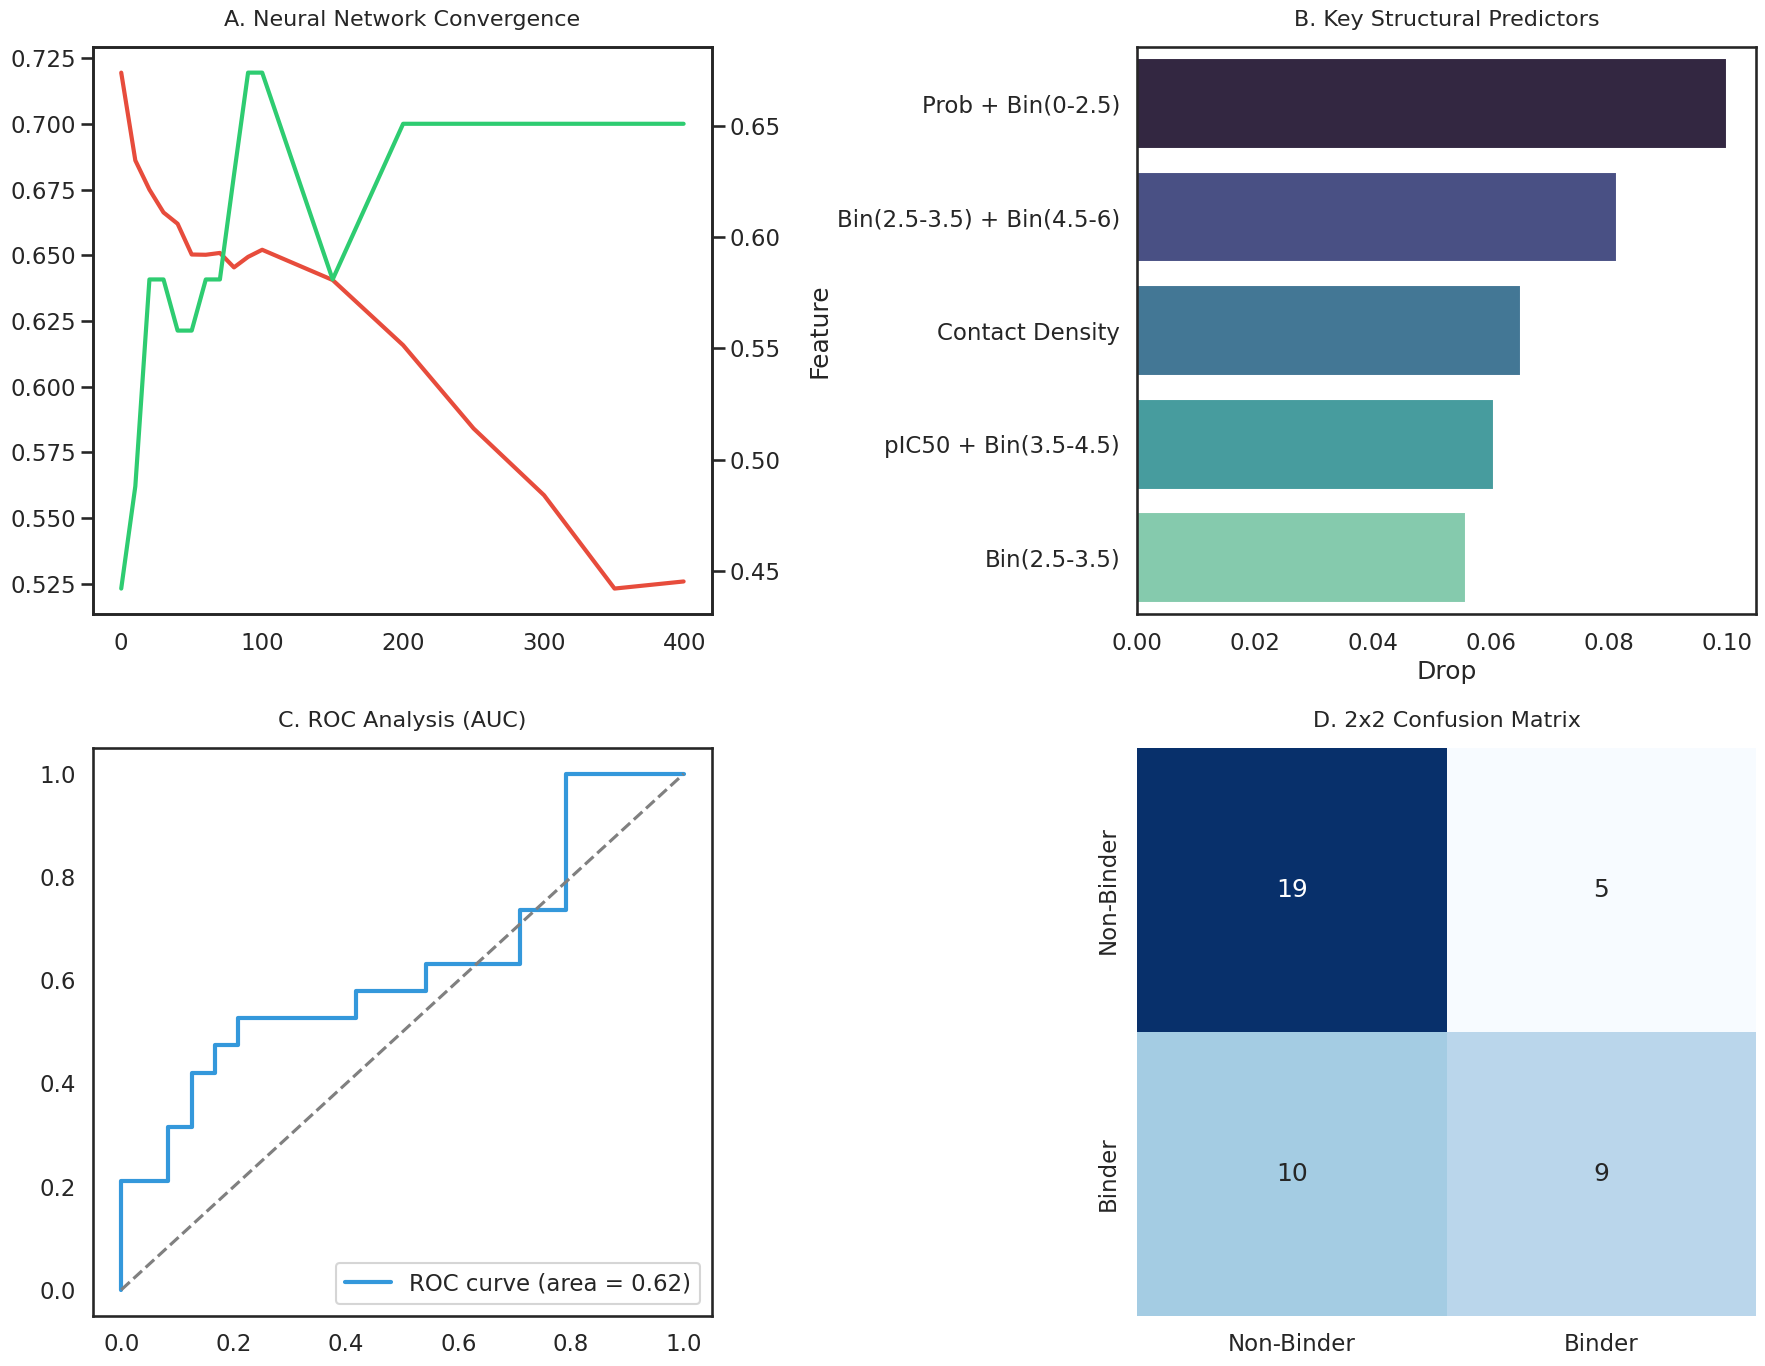


📊 HELD-OUT DATA CLASSIFICATION REPORT


,precision,recall,f1-score,support
Non-Binder,0.655,0.792,0.717,24.000
Binder,0.643,0.474,0.545,19.000
accuracy,0.651,0.651,0.651,0.651
macro avg,0.649,0.633,0.631,43.000
weighted avg,0.650,0.651,0.641,43.000


In [19]:
# @title Generate Training & Performance Summary (Table Output)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import pandas as pd
import torch

# 1. CALCULATE PERFORMANCE METRICS
best_model.eval()
with torch.no_grad():
    y_probs = best_model(X_test_t).numpy()
    y_preds = (y_probs > 0.5).astype(int)

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
cm = confusion_matrix(y_test, y_preds)

# 2. PLOTTING WITH TRANSPARENCY
sns.set_theme(style="white", context="talk")
fig, axes = plt.subplots(2, 2, figsize=(18, 14), facecolor='none')
((ax1, ax2), (ax3, ax4)) = axes

# A. TRAINING CURVES
ax1b = ax1.twinx()
ax1.plot(epochs, loss, color='#e74c3c', lw=3, label='Loss (BCE)')
ax1b.plot(epochs, accuracy, color='#2ecc71', lw=3, label='Test Accuracy')
ax1.set_title('A. Neural Network Convergence', fontsize=16, pad=15)
ax1.set_facecolor('none')

# B. FEATURE IMPORTANCE
sns.barplot(x='Drop', y='Feature', data=importance_data, palette='mako', ax=ax2)
ax2.set_title('B. Key Structural Predictors', fontsize=16, pad=15)
ax2.set_facecolor('none')

# C. ROC CURVE (AUC)


ax3.plot(fpr, tpr, color='#3498db', lw=3, label=f'ROC curve (area = {roc_auc:.2f})')
ax3.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax3.set_title('C. ROC Analysis (AUC)', fontsize=16, pad=15)
ax3.legend(loc="lower right")
ax3.set_facecolor('none')

# D. CONFUSION MATRIX

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4, cbar=False)
ax4.set_title('D. 2x2 Confusion Matrix', fontsize=16, pad=15)
ax4.set_xticklabels(['Non-Binder', 'Binder'])
ax4.set_yticklabels(['Non-Binder', 'Binder'])
ax4.set_facecolor('none')

plt.tight_layout()
plt.savefig("model_performance_transparent.png", dpi=300, transparent=True)
plt.show()

# 3. OUTPUT METRICS AS A CLEAN TABLE
print("\n" + "="*50)
print("HELD-OUT DATA CLASSIFICATION REPORT")
print("="*50)

# Convert classification report to a DataFrame for tabular display
report_dict = classification_report(y_test, y_preds,
                                   target_names=['Non-Binder', 'Binder'],
                                   output_dict=True)

df_report = pd.DataFrame(report_dict).transpose()

# Format the table for better readability
display(df_report.style.format(precision=3).background_gradient(cmap='Greens', subset=['precision', 'recall', 'f1-score']))